# Demo: End-to-End GNN–BERT Music Context Inference

This notebook runs one full inference example through the pipeline:

1. Generate/load a track's audio features (mel + chroma)
2. Build its music structure graph (segment-similarity graph)
3. Encode its text context (tags/caption) with the BERT(-analogue) encoder
4. Fuse graph + text representations (cross-attention, Task 3)
5. Predict multi-label tags + valence/arousal
6. (Bonus) Run Task 4 contrastive retrieval: given a caption, retrieve the closest audio graphs

Runs out-of-the-box on synthetic data — no dataset download required.
Swap in real audio via `src/audio_features.load_audio` once FMA / MagnaTagATune
/ MusicCaps are downloaded (see `README.md`).

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt

from audio_features import synthetic_track, segment_windows, segment_embedding
from graph_builder import build_segment_similarity_graph, estimate_chord_sequence, build_chord_transition_graph
from datasets import make_synthetic_dataset, train_val_test_split
from bert_encoder import SimpleTextEncoder
from gnn_model import NumpyGraphSAGE
from fusion_model import NumpyFusionModel
from contrastive import NumpyDualEncoder, recall_at_k
from evaluate import macro_micro_f1, auc_pr

np.random.seed(42)

## 1. One track: audio features -> segments -> graph

mel: (128, 1300)  chroma: (12, 1300)
4 segments of shape (12, 344)
segment-similarity graph: SimpleGraph(nodes=4, edges=6)


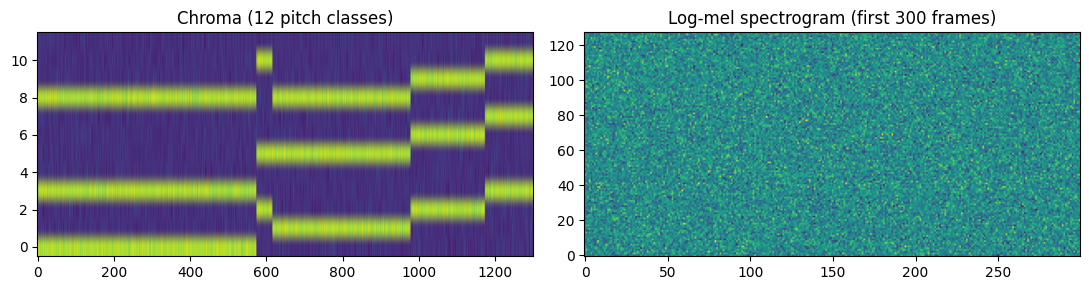

In [2]:
track = synthetic_track(seed=7)
print("mel:", track["mel"].shape, " chroma:", track["chroma"].shape)

segments = segment_windows(track["chroma"], sr=track["sr"], window_seconds=8.0)
embeddings = [segment_embedding(s) for s in segments]
print(f"{len(segments)} segments of shape {segments[0].shape}")

graph = build_segment_similarity_graph(embeddings, tau=0.85)
print("segment-similarity graph:", graph)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].imshow(track["chroma"], aspect="auto", origin="lower")
axes[0].set_title("Chroma (12 pitch classes)")
axes[1].imshow(track["mel"][:, :300], aspect="auto", origin="lower")
axes[1].set_title("Log-mel spectrogram (first 300 frames)")
plt.tight_layout(); plt.show()

## 2. Text context: BERT(-analogue) tag classifier (Task 1)

In [3]:
num_tags = 12
text_encoder = SimpleTextEncoder(hidden_dim=32, num_tags=num_tags, seed=42)

caption = "jazz track featuring piano, slow tempo, soft dynamics, mellow brass"
probs, cls_embedding = text_encoder.forward([caption])
print("CLS-analogue embedding shape:", cls_embedding.shape)
print("tag probabilities:", np.round(probs[0], 3))

CLS-analogue embedding shape: (1, 32)
tag probabilities: [0.535 0.53  0.501 0.48  0.468 0.461 0.488 0.504 0.495 0.485 0.521 0.518]


## 3. Fusion (Task 3): cross-attention over graph + text, multi-task prediction

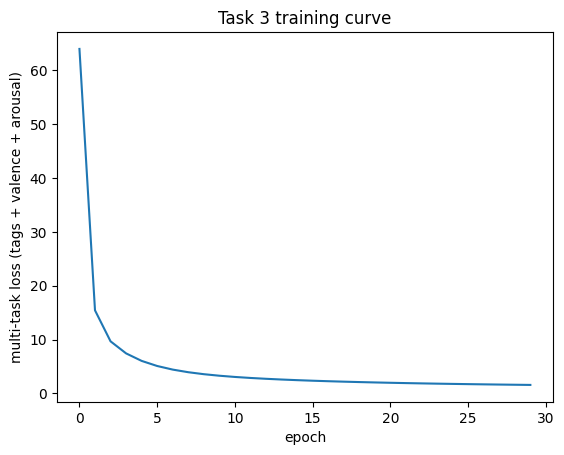

In [4]:
ds = make_synthetic_dataset(n_samples=120, num_tags=num_tags, graph_type="segment", seed=42)
splits = train_val_test_split(ds, seed=42)

g_dim = ds[0].graph.x.shape[1]
t_dim, z_dim = 32, 24
fusion_text_encoder = SimpleTextEncoder(hidden_dim=t_dim, num_tags=num_tags, seed=42)
fusion_model = NumpyFusionModel(g_dim=g_dim, t_dim=t_dim, z_dim=z_dim, num_tags=num_tags, seed=42)

def sample_pairs(subset, L=6):
    pairs, tags, emos = [], [], []
    for s in subset:
        g = s.graph.x.mean(axis=0)
        H_text = np.stack([fusion_text_encoder._hash_embed(tok)
                            for tok in (s.text.split() + [""] * L)[:L]])
        pairs.append((g.astype(np.float32), H_text.astype(np.float32)))
        tags.append(s.tags)
        emos.append(np.array([s.valence, s.arousal], dtype=np.float32))
    return pairs, np.stack(tags), np.stack(emos)

train_pairs, train_tags, train_emos = sample_pairs(splits["train"])
losses = [fusion_model.train_step(train_pairs, train_tags, train_emos, lr=0.1) for _ in range(30)]
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("multi-task loss (tags + valence + arousal)")
plt.title("Task 3 training curve"); plt.show()

### Inference on one held-out track

Predicted tag probs: [0.769 0.412 0.752 0.512 0.685 0.133 0.203 0.634 0.469 0.745 0.545 0.282]
Ground-truth tags:   [1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0.]
Predicted valence/arousal: 7.69 / 6.93
Ground-truth valence/arousal: 7.79 / 7.11


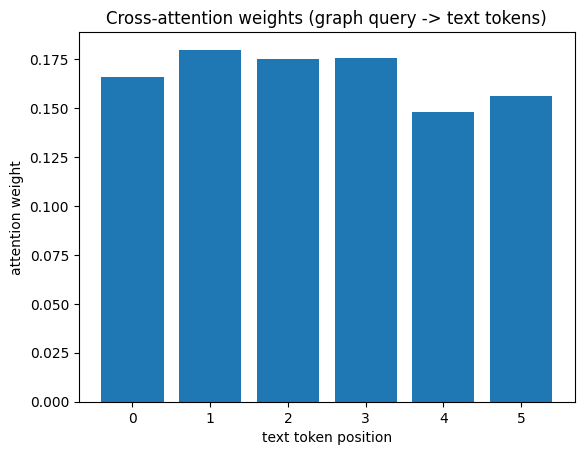

In [5]:
test_pairs, test_tags, test_emos = sample_pairs(splits["test"])
g0, H0 = test_pairs[0]
probs, emotion, z, attn_weights = fusion_model.forward(g0, H0)

print("Predicted tag probs:", np.round(probs, 3))
print("Ground-truth tags:  ", test_tags[0])
print(f"Predicted valence/arousal: {emotion[0]:.2f} / {emotion[1]:.2f}")
print(f"Ground-truth valence/arousal: {test_emos[0,0]:.2f} / {test_emos[0,1]:.2f}")

plt.bar(range(len(attn_weights)), attn_weights)
plt.title("Cross-attention weights (graph query -> text tokens)")
plt.xlabel("text token position"); plt.ylabel("attention weight"); plt.show()

## 4. Contrastive retrieval (Task 4): caption -> best-matching audio graph

In [6]:
ds4 = make_synthetic_dataset(n_samples=80, graph_type="segment", seed=42)
splits4 = train_val_test_split(ds4, seed=42)

t_dim = 32
dual_text_encoder = SimpleTextEncoder(hidden_dim=t_dim, num_tags=1, seed=42)
dual_model = NumpyDualEncoder(g_dim=ds4[0].graph.x.shape[1], t_dim=t_dim, embed_dim=64, seed=42)

def featurize(subset):
    G = np.stack([s.graph.x.mean(axis=0) for s in subset]).astype(np.float32)
    T = dual_text_encoder.encode_text([s.text for s in subset]).astype(np.float32)
    return G, T

G_train, T_train = featurize(splits4["train"])
for _ in range(60):
    loss = dual_model.train_step(G_train, T_train, lr=0.3, tau=0.07)

G_test, T_test = featurize(splits4["test"])
g_embed, t_embed = dual_model.encode(G_test, T_test)
metrics = recall_at_k(g_embed, t_embed, k_values=(1, 5, 10))
print("Retrieval metrics on held-out test set:", metrics)

query_idx = 0
sim = t_embed[query_idx] @ g_embed.T
top3 = np.argsort(-sim)[:3]
print(f"\nQuery caption: '{splits4['test'][query_idx].text}'")
for rank, idx in enumerate(top3, 1):
    print(f"  top-{rank}: '{splits4['test'][idx].text}' (sim={sim[idx]:.3f})")

Retrieval metrics on held-out test set: {'audio2text_R@1': 0.5833333333333334, 'text2audio_R@1': 0.6666666666666666, 'audio2text_R@5': 1.0, 'text2audio_R@5': 1.0, 'audio2text_R@10': 1.0, 'text2audio_R@10': 1.0}

Query caption: 'metal track featuring ambient, classic, new age, no vocal, opera, synth, woman'
  top-1: 'metal track featuring ambient, classic, new age, no vocal, opera, synth, woman' (sim=0.712)
  top-2: 'metal track featuring new age, no vocal, opera, slow, strings, synth, woman' (sim=0.679)
  top-3: 'metal track featuring female vocal, new age, no vocal, opera, piano, synth, woman' (sim=0.678)


## Next steps

- Replace `synthetic_track` with `audio_features.load_audio` on real FMA /
  MagnaTagATune / MusicCaps clips (see Table 1 in the project spec).
- Swap the `Simple*` / `Numpy*` fallback classes for the torch/PyG/transformers
  classes in `bert_encoder.py`, `gnn_model.py`, `fusion_model.py`,
  `contrastive.py` (used automatically once those libraries are installed).
- Run `src/train.py --task {1,2,3,4} --dataset <name>` once real data is
  cached under `data/processed/`.